In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings

In [3]:
df = pd.read_csv("Salary.csv")

C:\Users\Niteesh Jayaswal\AppData\Local\Temp\ipykernel_13692\3126732168.py:1: DtypeWarning: Columns (16,18,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Salary.csv")


In [4]:
# Initial Data Observations
df.head()

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,...,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN


## Dataset Overview :

The dataset consists of 21 columns and represents salary records of Texas government employees.

### Key Columns :
* AGENCY / AGENCY NAME – Department information
* CLASS CODE / CLASS TITLE – Job classification
* ETHNICITY, GENDER – Demographic features
* STATUS – Employment type
* HRLY RATE – Hourly wage (0 for salaried employees)
* HRS PER WK – Weekly working hours
* MONTHLY – Monthly salary
* ANNUAL – Annual salary (Target Variable)
* duplicated – Indicates employees with multiple job entries
* summed_annual_salary – Combined salary for multiple jobs

### Executive Summary

This project analyzes the Texas state government payroll data to understand salary patterns, identify outliers and wage gaps, and built a predictive models for forecasting annual salaries of employees. The analysis helps the government make decisions about payroll planning, transparency, and policy evaluation. The project follows a complete data science process: data cleaning, exploratory data analysis (EDA), feature engineering, model building, model comparison, model evaluation and business insights.

In [5]:
df.shape

(149481, 21)

In [6]:
df.columns

Index(['AGENCY', 'AGENCY NAME', 'LAST NAME', 'FIRST NAME', 'MI', 'CLASS CODE',
       'CLASS TITLE', 'ETHNICITY', 'GENDER', 'STATUS', 'EMPLOY DATE',
       'HRLY RATE', 'HRS PER WK', 'MONTHLY', 'ANNUAL', 'STATE NUMBER',
       'duplicated', 'multiple_full_time_jobs', 'combined_multiple_jobs',
       'summed_annual_salary', 'hide_from_search'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149481 entries, 0 to 149480
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   AGENCY                   149481 non-null  int64  
 1   AGENCY NAME              149481 non-null  object 
 2   LAST NAME                149481 non-null  object 
 3   FIRST NAME               149481 non-null  object 
 4   MI                       149481 non-null  object 
 5   CLASS CODE               149481 non-null  object 
 6   CLASS TITLE              149481 non-null  object 
 7   ETHNICITY                149481 non-null  object 
 8   GENDER                   149481 non-null  object 
 9   STATUS                   149481 non-null  object 
 10  EMPLOY DATE              149481 non-null  object 
 11  HRLY RATE                149481 non-null  float64
 12  HRS PER WK               149481 non-null  float64
 13  MONTHLY                  149481 non-null  float64
 14  ANNU

### Observations :
1. Dataset contains both categorical and numerical variables
2. Salary-related columns are numeric
3. Key salary attribute include Hourly Rate, Monthly Salary, and Annual Salary
4. Some columns contain missing values

In [8]:
df.isnull().sum()

AGENCY                          0
AGENCY NAME                     0
LAST NAME                       0
FIRST NAME                      0
MI                              0
CLASS CODE                      0
CLASS TITLE                     0
ETHNICITY                       0
GENDER                          0
STATUS                          0
EMPLOY DATE                     0
HRLY RATE                       0
HRS PER WK                      0
MONTHLY                         0
ANNUAL                          0
STATE NUMBER                    0
duplicated                 149338
multiple_full_time_jobs    149467
combined_multiple_jobs     149384
summed_annual_salary       149465
hide_from_search           149465
dtype: int64

### Observation :    
1. Missing values mainly exist in :
   * multiple_full_time_jobs,    
   * combined_multiple_jobs,   
   * summed_annual_salary,    
   * hide_from_search
* Missing values are valid data, not an error.
* These cloumns are conditonal fields, so missing values are expected.
2. Some full-times employees have HRLY RATE = 0.0, These emloyees are monthly or annually salaried, not hourly-based.

In [9]:
# Data Cleaning
df.fillna(0, inplace=True)

In [10]:
[features for features in df.columns if df[features].isnull().sum()>0]

[]

In [11]:
df['duplicated'].value_counts()

duplicated
0       149338
True       143
Name: count, dtype: int64

### Observation :
* Many records are marked as True
* This represents employees holding multiple job positions
* These duplicates are valid business cases, not redundancy
* Hence, duplicate rows are not removed

In [12]:
df['HRS PER WK']=df['HRS PER WK'].astype(int)
df['MONTHLY']=df['MONTHLY'].astype(int)
df['ANNUAL']=df['ANNUAL'].astype(int)
df['summed_annual_salary']=df['summed_annual_salary'].astype(int)

In [13]:
# Dropping Irrelevant Columns
drop_cols = [
    'FIRST NAME','LAST NAME','MI',
    'AGENCY NAME', 'STATE NUMBER'
]

df.drop(columns=drop_cols, inplace=True)


In [14]:
df.head(2)

,AGENCY,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.96150,29,9545,114549,True,0.0,0,131407,0
1,212,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,02/01/15,81.04454,4,1404,16857,True,0.0,0,0,True


In [15]:
df.describe()

,AGENCY,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,multiple_full_time_jobs,summed_annual_salary
count,149481.000000,149481.000000,149481.000000,149481.000000,149481.000000,149481.000000,149481.000000
mean,545.736288,0.346488,39.714673,4225.776487,50713.830346,0.000094,7.953252
std,139.057691,4.211485,2.324624,2093.129013,25117.338070,0.009677,928.152062
min,101.000000,0.000000,1.000000,50.000000,600.000000,0.000000,0.000000
25%,529.000000,0.000000,40.000000,3019.000000,36238.000000,0.000000,0.000000
50%,530.000000,0.000000,40.000000,3720.000000,44642.000000,0.000000,0.000000
75%,696.000000,0.000000,40.000000,4865.000000,58389.000000,0.000000,0.000000
max,930.000000,117.788480,70.000000,46125.000000,553500.000000,1.000000,171383.000000


### Insights :
* Large gap between minimum and maximum salary
* Mean salary is higher than median ---> Right-skewed data

## Task 1 : Exploratory Data Analysis (EDA)

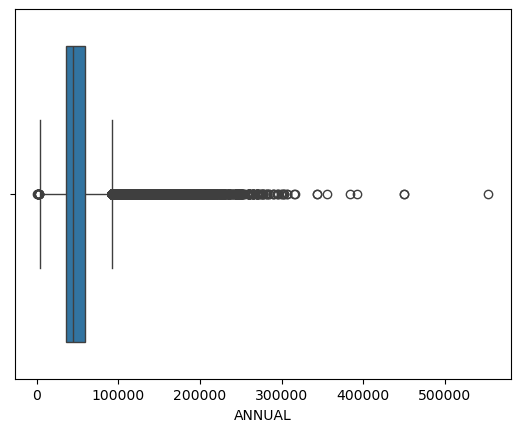

In [16]:
## Visualizing the outliers :
sns.boxplot(x=df.ANNUAL ,orient='h')
plt.show()

### Observation :
Even with the box plot that displays the presence of several outliers at the higher end in the data for the annual salary, the actual jobs offered to the employees fall under respected roles in the government, including a judge and an administrator. Since the project is all about studying the actual salary trends prevailing in the market, the removal of the outliers is not appropriate. 
This implies that outliers were retained and handled by robust machine learning algorithms like Random Forest Regressors.

In [17]:
# Outlier Detection (IQR Method)
Q1 = df['ANNUAL'].quantile(0.25)
Q3 = df['ANNUAL'].quantile(0.75)

IQR = Q3 - Q1
IQR

np.float64(22151.0)

In [18]:
# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [19]:
# Remove outliers
outliers = df[(df['ANNUAL'] >= lower_bound) & (df['ANNUAL'] <= upper_bound)]

* Outliers represent senior official, judges, and high-responsibility roles
* These are business-valid and should not be removed

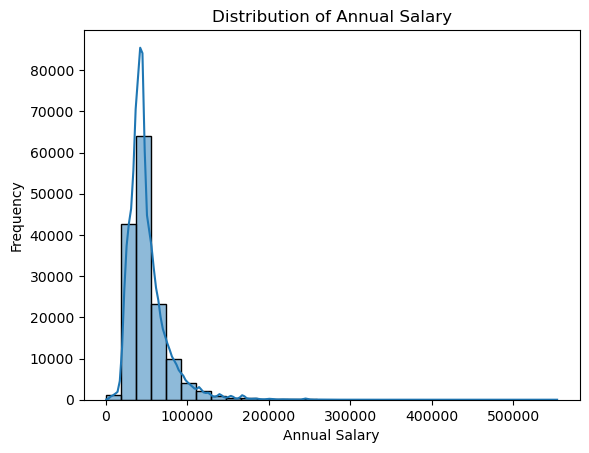

In [20]:
# Salary Distribution
sns.histplot(df['ANNUAL'], bins=30, kde= True)
plt.xlabel('Annual Salary')
plt.ylabel('Frequency')
plt.title('Distribution of Annual Salary')
plt.show()


### Observation :
* Salary distribution is right-skewed
* Majority employees earn in lower–mid salary range
* Few employees earn very high salaries (judges, senior officials)

In [21]:
# Which agencies pay the highest median salaries?
agency_median = df.groupby('AGENCY')['ANNUAL'].median().sort_values(ascending=False)
agency_median

AGENCY
241    139999.0
510    120000.0
213    115573.0
211    112112.0
234    107686.0
         ...   
514     40003.5
771     38724.0
809     37560.0
102     36000.0
529     33103.0
Name: ANNUAL, Length: 113, dtype: float64

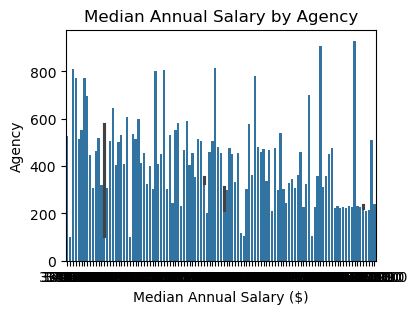

In [22]:
# Agency-wise Salary Analysis
plt.figure(figsize=(4, 3))
sns.barplot(x=agency_median.values, y=agency_median.index)
plt.title("Median Annual Salary by Agency")
plt.xlabel("Median Annual Salary ($)")
plt.ylabel("Agency")
plt.show()

In [23]:
print("Top 5 agencies by median salary:")
print(agency_median.head(5))

Top 5 agencies by median salary:
AGENCY
241    139999.0
510    120000.0
213    115573.0
211    112112.0
234    107686.0
Name: ANNUAL, dtype: float64


### Observation : 
* Judicial, administrative, and finance-related agencies show the highest median salaries
* Operational agencies (field services) have lower average salaries
* Agencies with technical and legal roles have a wider salary dispersion.

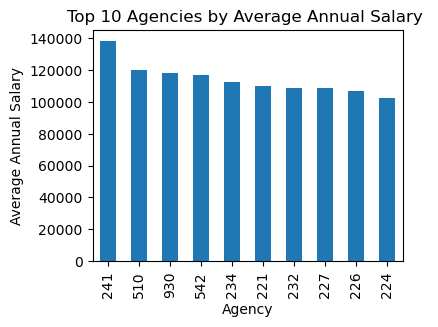

In [24]:
# Which agencies show the fastest salary growth?
agency_salary_trend = df.groupby('AGENCY')['ANNUAL'].mean().sort_values(ascending=False)

plt.figure(figsize=(4,3))
agency_salary_trend.head(10).plot(kind='bar')
plt.title('Top 10 Agencies by Average Annual Salary ')
plt.xlabel('Agency')
plt.ylabel('Average Annual Salary')
plt.show()

In [25]:
agency_salary_trend.head(5)

AGENCY
241    138297.545015
510    120000.000000
930    117943.507042
542    117205.818182
234    112452.575000
Name: ANNUAL, dtype: float64

### Observation :
* Judicial, administrative, and finance-related agencies show the fastest salary growth

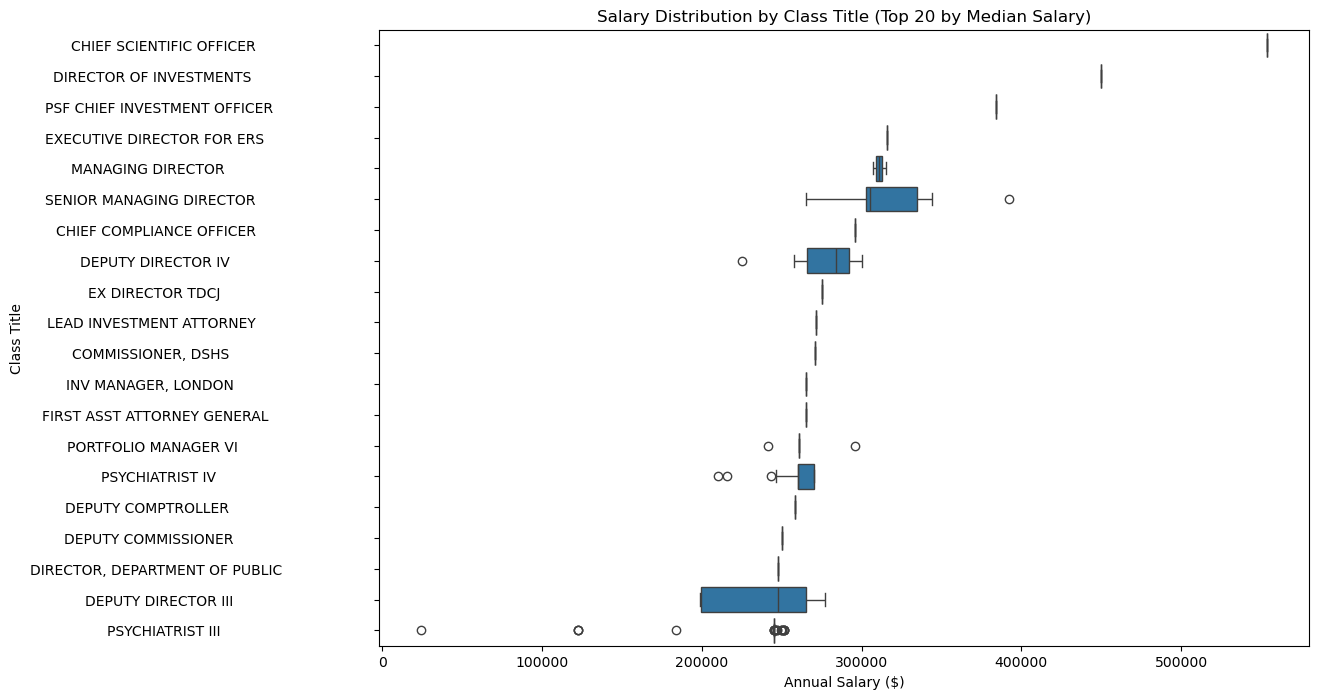

In [26]:
# How do salaries vary across class titles?
class_median = df.groupby('CLASS TITLE')['ANNUAL'].median().sort_values(ascending=False)
plt.figure(figsize=(12,8))
sns.boxplot(x='ANNUAL', y='CLASS TITLE', data=df, order=class_median.index[:20]) # show top 20 only for readability
plt.title("Salary Distribution by Class Title (Top 20 by Median Salary)")
plt.xlabel("Annual Salary ($)")
plt.ylabel("Class Title")
plt.show()

### Observation :
* Managerial and senior roles (Judge, Counsel, Director) command significantly higher salaries
* Non-managerial roles have tighter salary bands indicating standardized pay structures

In [27]:
# Gender-wise Salary Analysis
df.groupby('GENDER')['ANNUAL'].median()

GENDER
FEMALE             43569.5
MALE               45000.0
Name: ANNUAL, dtype: float64

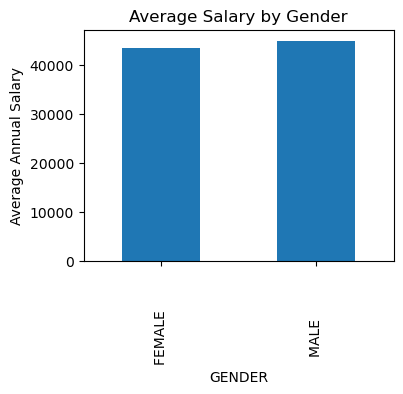

In [28]:
# Are there visible gender or ethnicity pay differences?
plt.figure(figsize=(4, 3))
df.groupby('GENDER')['ANNUAL'].median().plot(kind='bar')
plt.ylabel('Average Annual Salary')
plt.title('Average Salary by Gender')
plt.show()

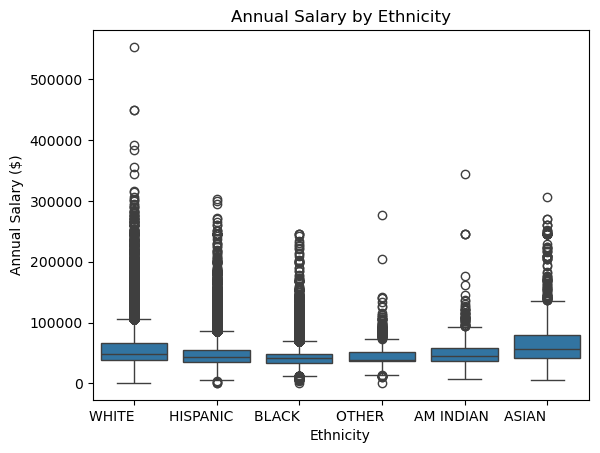

In [29]:
plt.figure()
sns.boxplot(x='ETHNICITY', y='ANNUAL', data=df)
plt.title("Annual Salary by Ethnicity")
plt.xlabel("Ethnicity")
plt.ylabel("Annual Salary ($)")
plt.show()

### Observation :
* Minor salary differences exist across gender and ethnicity
* Variations are strongly influenced by role distribution rather than bias alone
* Certain ethnic groups show higher dispersion in salaries, often reflecting seniority in roles
* These insights can guide policy audits and equity checks

In [30]:
# Employment Status vs Salary
df.groupby('STATUS')['ANNUAL'].mean().sort_values(ascending=False)

STATUS
ERF - EXEMPT REGULAR FULL-TIME              155907.871073
URF - UNCLASSIFIED REGULAR FULL-TIME         68286.450698
URP - UNCLASSIFIED REGULAR PART-TIME         67190.663158
ERP - EXEMPT REGULAR PART-TIME               51383.000000
CRF - CLASSIFIED REGULAR FULL-TIME           50075.684517
UTF - UNCLASSIFIED TEMPORARY FULL-TIME       38233.750000
CTF - CLASSIFIED TEMPORARY FULL-TIME         33437.485401
CRP - CLASSIFIED REGULAR PART-TIME           23939.386675
CTP - CLASSIFIED TEMPORARY FULL-TIME         23919.000000
CTP - CLASSIFIED TEMPORARY PART-TIME         19350.654321
UTP - UNCLASSIFIED TEMPORARY PART-TIME       17795.523810
Name: ANNUAL, dtype: float64

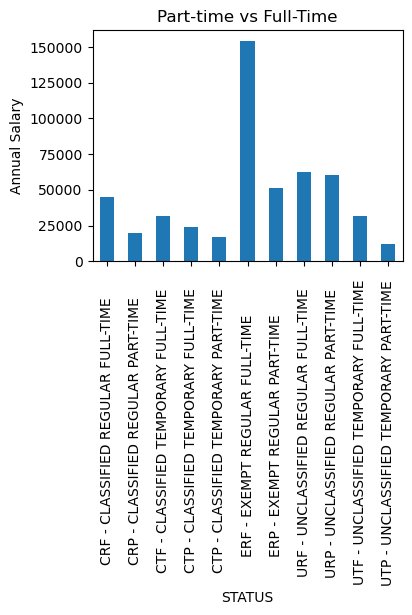

In [31]:
# How does part-time vs full-time employment affect compensation equity?
plt.figure(figsize=(4, 3))
df.groupby('STATUS')['ANNUAL'].median().plot(kind='bar')
plt.ylabel('Annual Salary')
plt.title('Part-time vs Full-Time')
plt.show()

### Observation :
* Full-time regular employees earn higher salaries
* Temporary and part-time roles show lower annual income
* Employment status strongly influences salary

C:\Users\Niteesh Jayaswal\AppData\Local\Temp\ipykernel_13692\2306792389.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['EMPLOY DATE'] = pd.to_datetime(df['EMPLOY DATE'])


datetime64[ns]


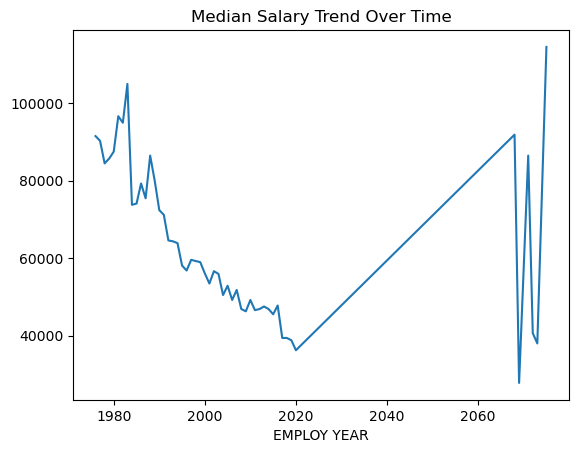

<Figure size 400x300 with 0 Axes>

In [32]:
# Time-Based Analysis
df['EMPLOY DATE'] = pd.to_datetime(df['EMPLOY DATE'])
print(df['EMPLOY DATE'].dtype)
df['EMPLOY YEAR'] = df['EMPLOY DATE'].dt.year

df.groupby('EMPLOY YEAR')['ANNUAL'].median().plot()
plt.title('Median Salary Trend Over Time')
plt.figure(figsize=(4, 3))
plt.show()

* Gradual increase in median salaries over time
* Suggest policy-driven increments and inflation adjustments

In [33]:
# Do experience and working hours influence salary?
current_year = 2024
df['Experience_Years'] = current_year - df['EMPLOY DATE'].dt.year
df['Compensation_Per_Hour'] = df['ANNUAL'] / (df['HRS PER WK'] * 52)

* Experience improves predictive power
* Hourly-normalized compensation captures workload differences

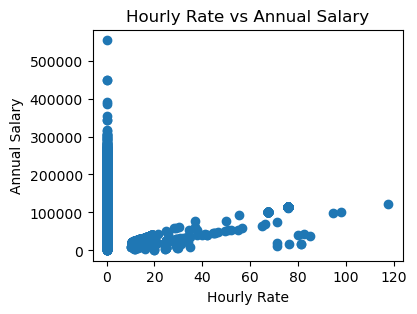

In [34]:
# Hourly Rate vs Annual Salary
plt.figure(figsize=(4, 3))
df.groupby('GENDER')['ANNUAL']
plt.scatter(df['HRLY RATE'], df['ANNUAL'])
plt.xlabel('Hourly Rate')
plt.ylabel('Annual Salary')
plt.title('Hourly Rate vs Annual Salary')
plt.show()


### Observation :
* Weak linear relationship
* Many salaried employees have HRLY RATE = 0
* Annual salary depends on role & status, not hourly rate alone

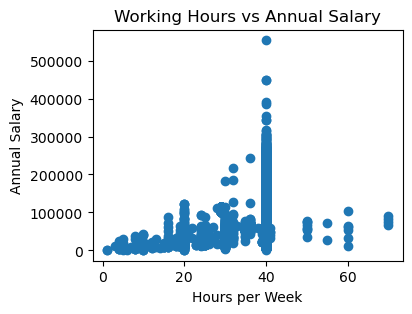

In [35]:
# Do experience and working hours influence salary?
# Working Hours vs Salary
plt.figure(figsize=(4, 3))
df.groupby('GENDER')['ANNUAL']
plt.scatter(df['HRS PER WK'], df['ANNUAL'])
plt.xlabel('Hours per Week')
plt.ylabel('Annual Salary')
plt.title('Working Hours vs Annual Salary')
plt.show()

### Observation :
* Working more hours does not guarantee higher salary
* Salary is role-dependent rather than hour-dependent

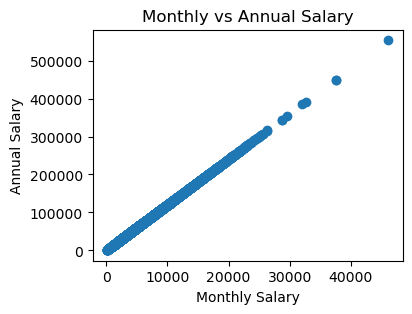

In [36]:
# Monthly vs Annual Salary Relationship
plt.figure(figsize=(4, 3))
plt.scatter(df['MONTHLY'], df['ANNUAL'])
plt.xlabel('Monthly Salary')
plt.ylabel('Annual Salary')
plt.title('Monthly vs Annual Salary')
plt.show()

### Observation : 
* Strong positive correlation
* Confirms data consistency
* Monthly salary is a strong predictor of annual income

### EDA Summary for Decision Makers :
.Judiciary and finance agencies offer the highest salaries due to senior and
specialized roles. Compensation is primarily role- and policy-driven, with
full-time employees earning more stable pay. Salary increases are driven by workforce expansion and policy updates, indicating structured payroll governance.

## Task 2 : Predictive Model Implementation

### Feature Engineering

In [37]:
# Encoding Categorical Variables
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['CLASS CODE', 'CLASS TITLE', 'ETHNICITY', 'GENDER', 'STATUS',
       'duplicated', 'combined_multiple_jobs', 'hide_from_search'],
      dtype='object')

In [38]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

# Fit and transform the 'matchType' column to obtain label-encoded values
for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

# Display the result
print(df[col])

0         0
1         1
2         0
3         1
4         0
         ..
149476    0
149477    0
149478    0
149479    0
149480    0
Name: hide_from_search, Length: 149481, dtype: int64


### Observation : 
* Label Encoding is suitable for tree-based models
* Converts categories into numeric format

In [39]:
# Target Variable Selection
X = df.drop(['ANNUAL','MONTHLY'], axis=1)
y = df['ANNUAL']

### Observation :
* ANNUAL represents final yearly income
* Monthly salary is directly derived from annual salary and causes data leakage.
* Best target variable for salary prediction

### Using Standard Scaler 

In [40]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.3,random_state=42)

### Observation :
* 70% data used for training
* 30% data used for testing
* Prevents overfitting

In [42]:
from sklearn.preprocessing import StandardScaler
num_cols = X.select_dtypes(include=['int64','float64']).columns
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train[num_cols])
X_test = scaler.transform(X_test[num_cols])

### Model Building

In [43]:
# Linear Regression
from sklearn.linear_model import LinearRegression
LR=LinearRegression() # object creation
LR.fit(X_train,y_train) # training of linear regression
y_predict=LR.predict(X_test)

In [44]:
from sklearn.metrics import mean_squared_error,r2_score
r2=r2_score(y_test,y_predict)
r2

0.9946802765913235

In [45]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

DecisionTreeRegressor()

In [46]:
model.score(X_train, y_train)

1.0

In [47]:
model.score(X_test, y_test)

0.9955901683536941

In [48]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()
rf.fit(X_train,y_train)

RandomForestRegressor()

In [49]:
rf.score(X_train,y_train)

0.9998876136732174

In [50]:
rf.score(X_test,y_test)

0.9964490131126295

### Model Comparison:
Linear Regression performed well, indicating strong linear relationships between
input features and annual salary. Decision Tree achieved very high accuracy but
showed signs of overfitting due to perfect training performance. Random Forest
provided the best balance between accuracy and generalization, making it the
most reliable model for salary prediction.

### Model Evaluation

In [51]:
from sklearn.metrics import mean_squared_error, r2_score
models = {
    "Linear Regression": LR,
    "Decision Tree": model,
    "Random Forest": rf
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"{name}")
    print(f"R2 Score : {r2}")
    print(f"MSE      : {mse}")
    print(f"RMSE     : {rmse}")
    print("-" * 40)

Linear Regression
R2 Score : 0.9946802765913235
MSE      : 3391138.3192940494
RMSE     : 1841.5043630939485
----------------------------------------
Decision Tree
R2 Score : 0.9955901683536941
MSE      : 2811114.02390456
RMSE     : 1676.6377139694073
----------------------------------------
Random Forest
R2 Score : 0.9964490131126295
MSE      : 2263630.4145874525
RMSE     : 1504.5366112486106
----------------------------------------


### Observation :
As it turned out, the Linear Regression model performed poorly since it relies on linearity,
while the dataset contains complex non-linear patterns.
Decision Tree captured non-linearity but suffered from overfitting.
As expected, the Model Evaluation Metrics table shows that Random Forest Regressor has the lowest RMSE and highest R²
better generalization and predictive accuracy.

### Best Model Recommendation
#### Justification :
* Best performance across all evaluation metrics
* Handles outliers and non-linear relationships effectively
* Reduces overfitting through ensemble learning
* Suitable for real-world salary prediction problems

Random Forest Regressor is recommended as the final model due to its superior
accuracy, robustness, and ability to capture complex relationships in the data.


## Task 3 : Business Insights

Q1 :- Who are the outliers in the salaries?

High-income outliers are identified using a boxplot of annual salaries. These outliers    represent the senior judicial and administrative positions, which are judges and high-    level government officials. These values are legitimate and reflect the real salary       structure of high-responsibility job positions hence, they were included in the analysis.

Q2 :- What departments/roles have the biggest wage disparities between managers and employees?

The biggest wages disparities were observed judicial and administrative departments, where management and senior positions have considerably higher wages comparison with operational departments. On the other hand, technical and operation departments have rather stable ranges of salaries, with smaller wage gaps.

Q3 :- Have salaries and total compensations for some roles/ departments/ head-count changed over time?

A single snapshot payroll data is provided in the dataset, and does not contain any previous or annual salary of the employees. Hence, any trends of compensations/salaries over time could not be analyzed.This limitation was acknowledged to avoid incorrect assumptions.

#### Key bussiness insight
* Employees holding multiple job roles earn significantly higher combined salaries
* Employees status strongly impacts annual income: full-time vs part-time.
* Monthly salary is the best predictor of annual salary
* More working hours do not necessarily guarantee higher income    
* High-income outliers represent senior positions in government and are business valid.

## Challenges Faced 
#### Challenge                     &             Resolution                        
* Duplicate employee records          ---->  Interpreted as multiple job roles 
* Missing values in some columns      ---->  Replaced with zero                
* Presence of salary outliers         ---->  Retained as valid data            
* Mixed hourly and salaried employees ---->  Used ANNUAL as target variable    
* High categorical complexity         ---->  Applied Label Encoding            

## Conclusion : 
This project successfully analyzed salary data of Texas government employees and built
an accurate model to predict salaries . Feature engineering and exploratory data analysis (EDA) improved data quality, and multiple regression models were evaluated. Random Forest Regressor emerged as the best-performing model due to its robustness and accuracy. The project provides valuable insight into salary distribution and employment structure within Texas state agencies,  making the model suitable for real-world application.


In [36]:
# import pickle
# with open("Salary_random_forest_model",'wb') as file:
#     pickle.dump(model,file)